<a href="https://colab.research.google.com/github/Priyanshu-Dewangan/GrowthLink_projects/blob/main/Iris_Flower_Classification_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**

start the project by impoprting all the libraries that we will need in this project.

In [4]:
# Loading Important Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Reading the dataset

In [5]:
df = pd.read_csv("/content/IRIS.xls")
df.shape


(150, 5)

In [6]:
# print the first 10 rows of the dataframe
df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


# Explore the data

Checking column names

In [7]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [8]:
#distribution of target_class column
df['species'].value_counts()

,count
species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [9]:
# check for missing values in variables

df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


# Descriptive Statistics:

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [11]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# Analysis & Visualization

In [12]:
df['species'].value_counts()

,count
species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


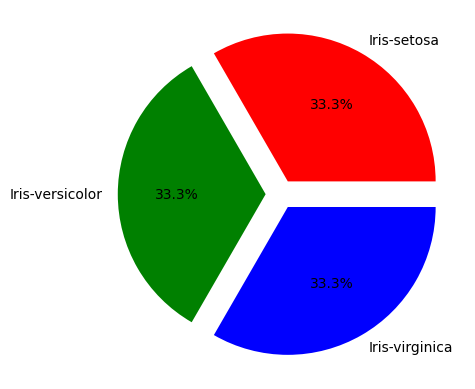

In [13]:
plt.pie(df['species'].value_counts(),
        labels= df['species'].unique(),
        autopct='%1.1f%%',
        explode=(.1, .1, .1),
        colors = ['red', 'green', 'blue'])
plt.show()

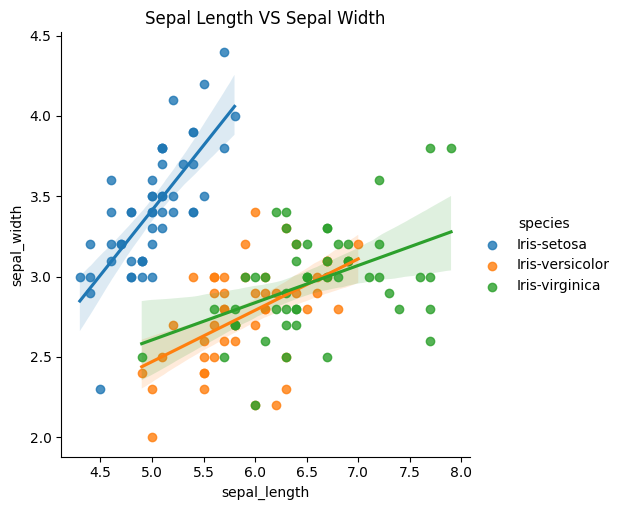

In [14]:
sns.lmplot(
    x="sepal_length",
    y="sepal_width",
    hue="species",
    data=df
)

plt.title("Sepal Length VS Sepal Width")
plt.show()

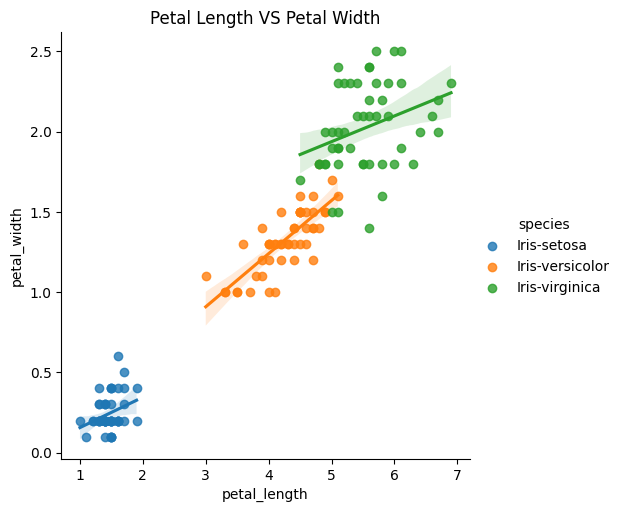

In [15]:
sns.lmplot(
    x="petal_length",
    y="petal_width",
    hue="species",
    data=df
)

plt.title("Petal Length VS Petal Width")
plt.show()

# Exploratory Data Analysis

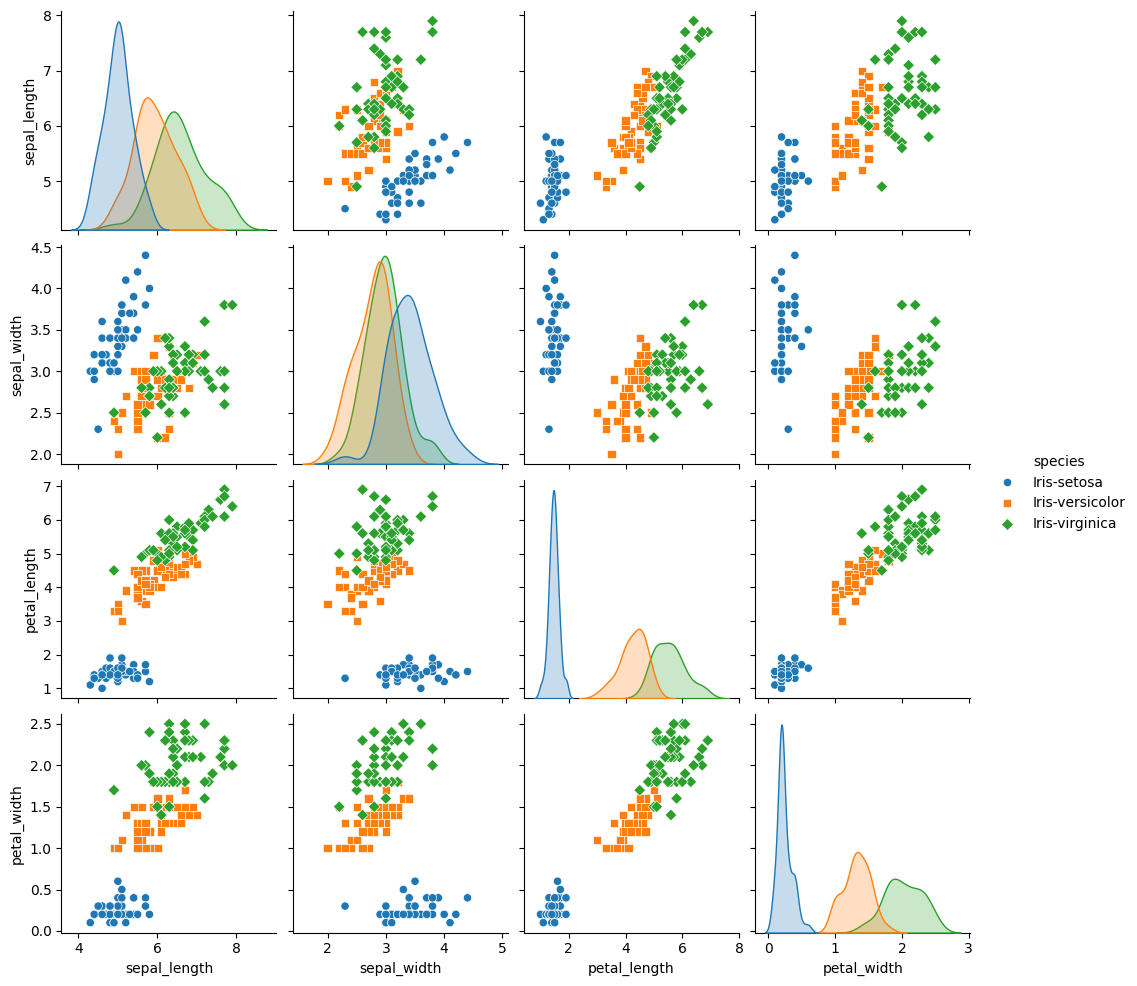

In [16]:
# Pairplot to visualize relationships between features
sns.pairplot(df, hue='species', markers=['o', 's', 'D'])
plt.show()

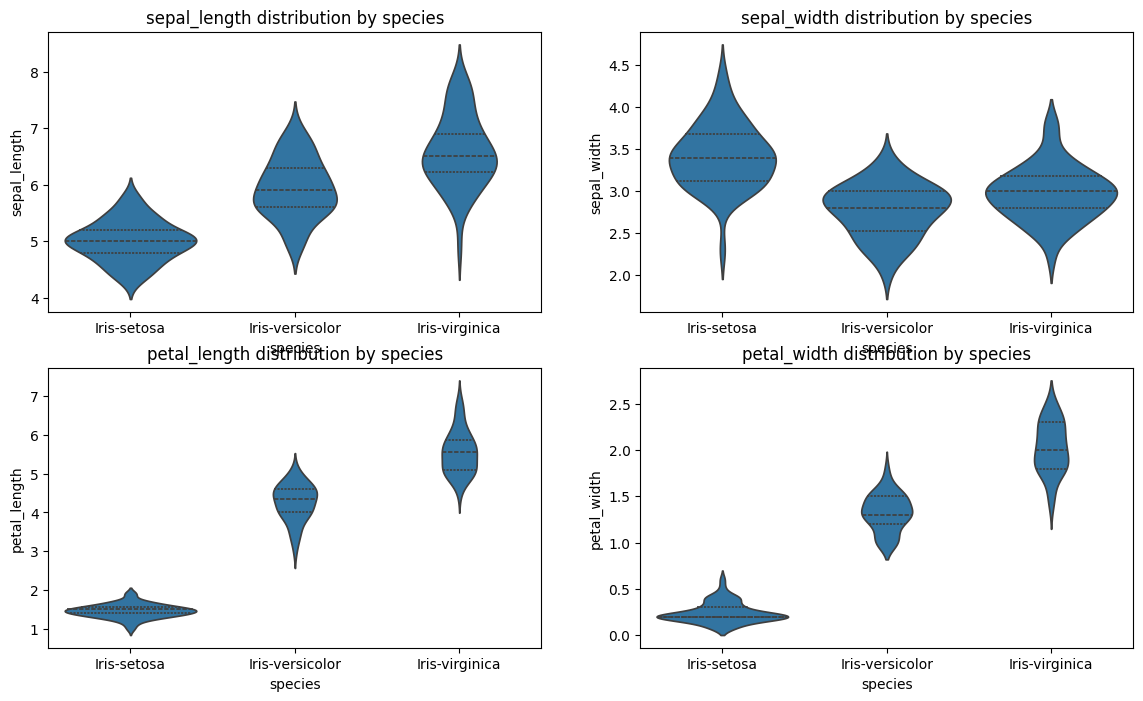

In [17]:
# Violin plots for each feature
plt.figure(figsize=(14, 8))
for i, column in enumerate(df.columns[:-1]):
    plt.subplot(2, 2, i + 1)
    sns.violinplot(x='species', y=column, data=df, inner='quartile')
    plt.title(f'{column} distribution by species')
plt.show()

Text(0, 0.5, 'petal_width')

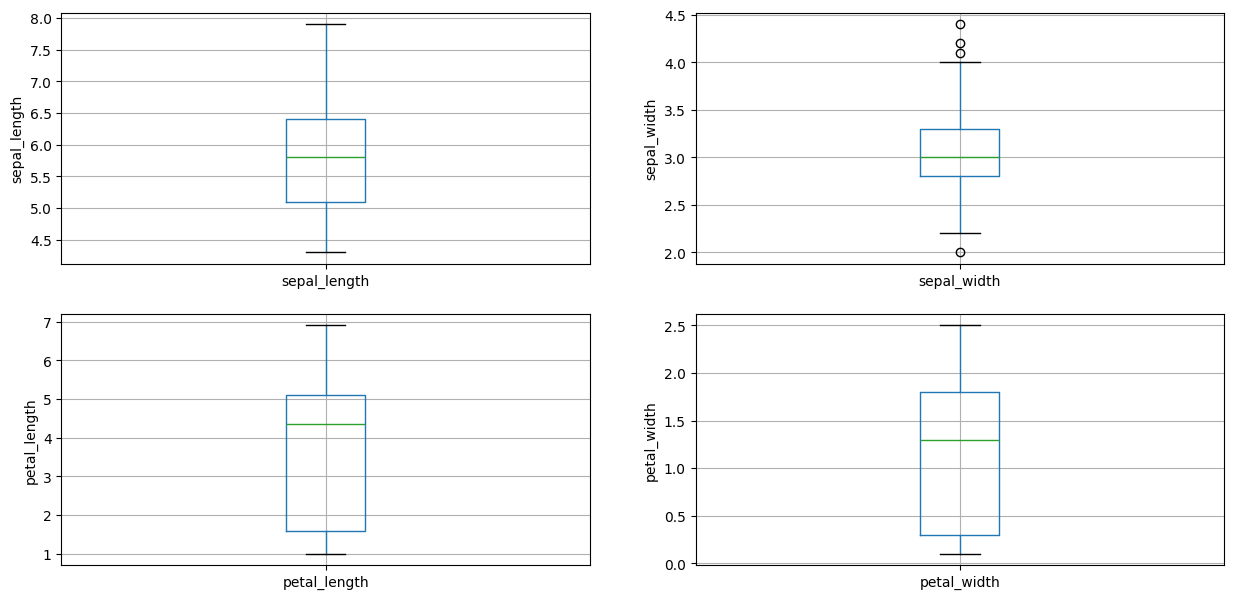

In [18]:
# Boxplots to visualize outliers

plt.figure(figsize=(15,15))


plt.subplot(4, 2, 1)
fig = df.boxplot(column='sepal_length')
fig.set_title('')
fig.set_ylabel('sepal_length')


plt.subplot(4, 2, 2)
fig = df.boxplot(column='sepal_width')
fig.set_title('')
fig.set_ylabel('sepal_width')


plt.subplot(4, 2, 3)
fig = df.boxplot(column='petal_length')
fig.set_title('')
fig.set_ylabel('petal_length')


plt.subplot(4, 2, 4)
fig = df.boxplot(column='petal_width')
fig.set_title('')
fig.set_ylabel('petal_width')

Text(0.5, 0, 'petal_width')

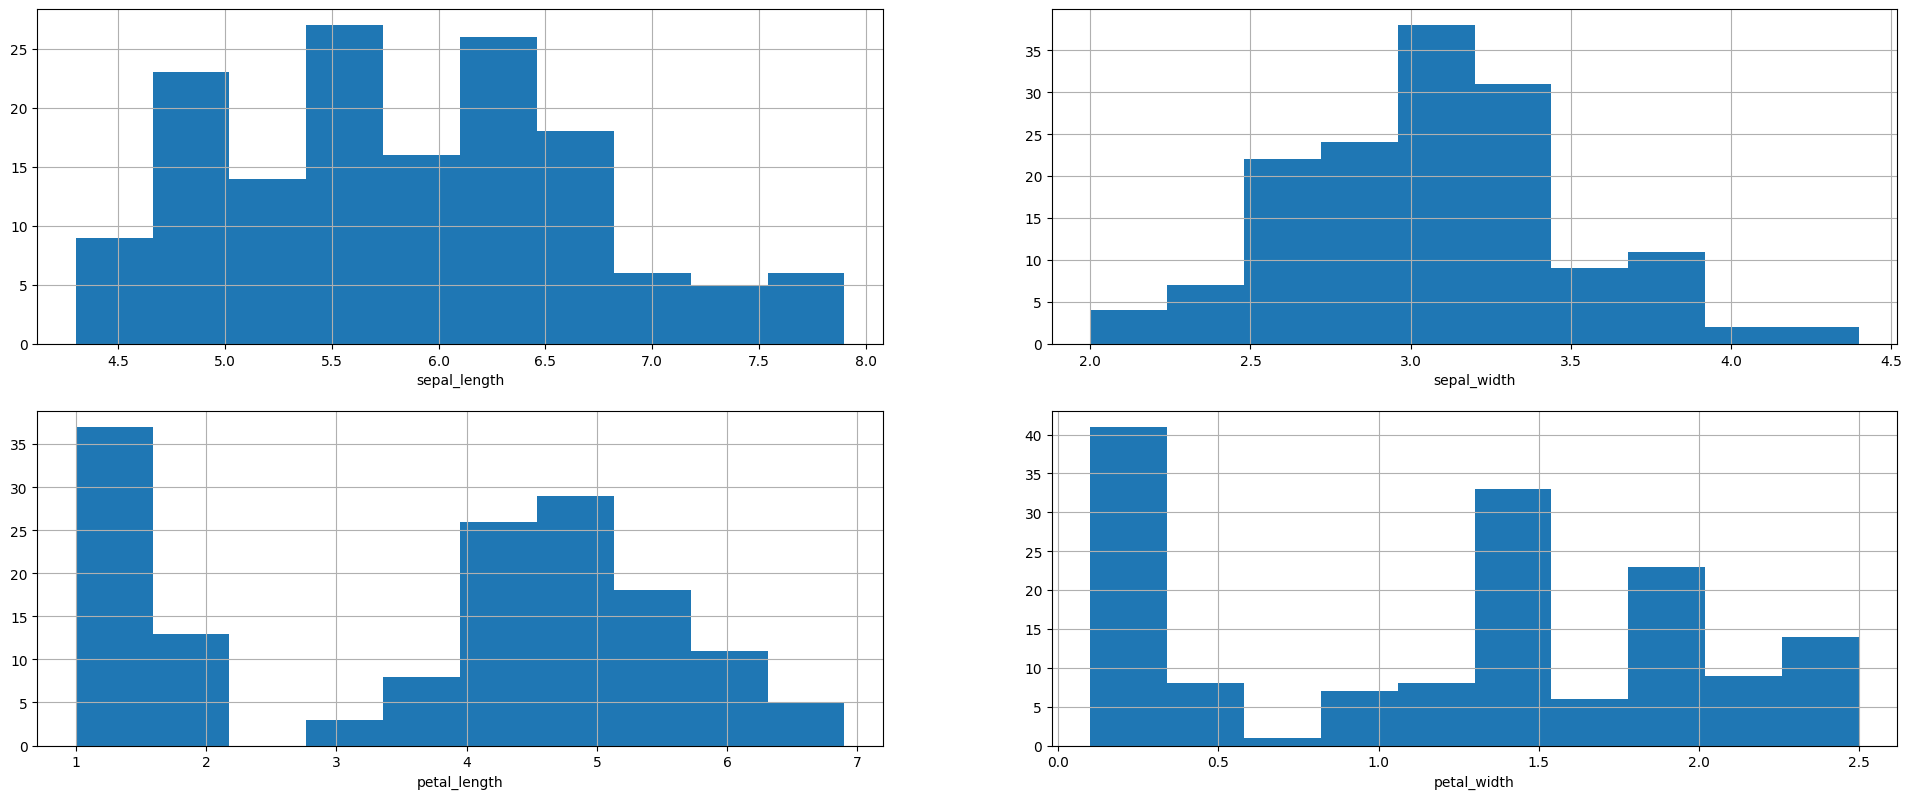

In [19]:
# plot histogram to check distribution


plt.figure(figsize=(24,20))


plt.subplot(4, 2, 1)
fig = df['sepal_length'].hist(bins=10)
fig.set_xlabel('sepal_length')



plt.subplot(4, 2, 2)
fig = df['sepal_width'].hist(bins=10)
fig.set_xlabel('sepal_width')



plt.subplot(4, 2, 3)
fig = df['petal_length'].hist(bins=10)
fig.set_xlabel('petal_length')



plt.subplot(4, 2, 4)
fig = df['petal_width'].hist(bins=10)
fig.set_xlabel('petal_width')

# Feature Extraction

In [20]:
X = df.drop(['species'], axis=1)

y = df['species']

In [21]:
# spliting X and y into training and testing sets

from sklearn.model_selection import train_test_split

X_train, x_test, Y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 10)

In [23]:
X_train.shape, x_test.shape

((112, 4), (38, 4))

# Model Selection

Logistic Regression Model

In [24]:
model1 = LogisticRegression()

In [25]:
model1.fit(X_train, Y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [26]:
model1.score(X_train, Y_train)

0.9732142857142857

In [28]:
model1.score(x_test, y_test)

1.0

In [27]:
model1.predict([[5.1,3.5,1.4,0.2]])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array(['Iris-setosa'], dtype=object)

In [29]:
y_pred1= model1.predict(x_test)
y_pred1

array(['Iris-versicolor', 'Iris-virginica', 'Iris-setosa',
       'Iris-versicolor', 'Iris-setosa', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-virginica',
       'Iris-versicolor', 'Iris-setosa', 'Iris-setosa', 'Iris-virginica',
       'Iris-versicolor', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-virginica', 'Iris-virginica', 'Iris-virginica',
       'Iris-setosa', 'Iris-versicolor', 'Iris-setosa', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-virginica',
       'Iris-virginica', 'Iris-virginica', 'Iris-setosa',
       'Iris-virginica', 'Iris-virginica'], dtype=object)

Support Vector Machine (SVM)

In [31]:
model2 = SVC()

model2.fit(X_train, Y_train)

SVC()

In [32]:
model2.score(x_test, y_test)

1.0

In [33]:
model2.score(X_train, Y_train)

0.9642857142857143

In [34]:
model2.predict([[4.8,3.0,1.5,0.3]])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array(['Iris-setosa'], dtype=object)

In [35]:
y_pred2 = model2.predict(x_test)
y_pred2

array(['Iris-versicolor', 'Iris-virginica', 'Iris-setosa',
       'Iris-versicolor', 'Iris-setosa', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-virginica',
       'Iris-versicolor', 'Iris-setosa', 'Iris-setosa', 'Iris-virginica',
       'Iris-versicolor', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-virginica', 'Iris-virginica', 'Iris-virginica',
       'Iris-setosa', 'Iris-versicolor', 'Iris-setosa', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-virginica',
       'Iris-virginica', 'Iris-virginica', 'Iris-setosa',
       'Iris-virginica', 'Iris-virginica'], dtype=object)



---



According to the results Best Model is Logistic Regression with :

---


Training Accuracy: 0.9732142857142857

---


Test Accuracy : 1.0

---


# Evaluation Results

<Axes: >

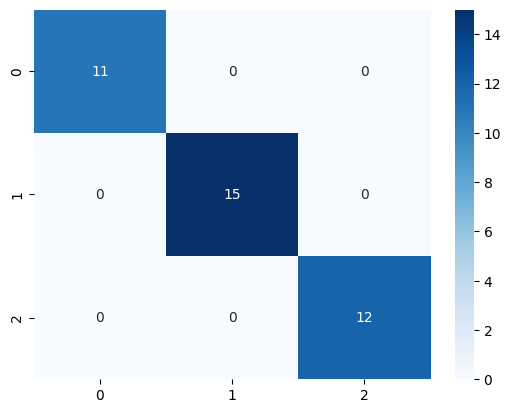

In [36]:
cm = confusion_matrix(y_test,y_pred1)
sns.heatmap(cm,annot=True,cmap='Blues')

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred1))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       1.00      1.00      1.00        15
 Iris-virginica       1.00      1.00      1.00        12

       accuracy                           1.00        38
      macro avg       1.00      1.00      1.00        38
   weighted avg       1.00      1.00      1.00        38



We have now successfully implemented machine learning model to classify Iris flowers into their respective species (Setosa, Versicolor, and Virginica) based on sepal and petal measurements.  Logistic Regression  and Support Vector Machine models were trained and evaluated, and their performance was compared.  Ultimately, the Logistic Regression achieved the highest accuracy of 97.32% on the train set and 100% on the test set, demonstrating its effectiveness in accurately classifying Iris species.